# 🔮 Customer Churn Prediction Pipeline

Complete ML pipeline: preprocessing, feature engineering, scaling, outlier detection, and model building.

| Day | Task |
|---|---|
| 1 | Load & Explore Data |
| 2 | Categorical Encoding (Label, Ordinal, One-Hot) |
| 3 | Feature Scaling (Standard + MinMax) |
| 4 | Outlier Detection (IQR + Z-Score) |
| 5 | Feature Engineering (6 new features) |
| 6 | Feature Selection (Correlation + Importance) |
| 7 | Full Pipeline + 3 Models |


## Imports & Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (
    LabelEncoder, OneHotEncoder, OrdinalEncoder,
    StandardScaler, MinMaxScaler
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Load & Explore Data

In [11]:
df = pd.read_csv('E:\The Developers Arena\Customer Churn Prediction\customer_churn.csv')

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"Shape: {df.shape}")
print(f"\nColumn Types:\n{df.dtypes}")
print(f"\nNull Values:\n{df.isnull().sum()}")
print(f"\nDescriptive Stats:\n{df.describe()}")
print(f"\nChurn Distribution:\n{df['Churn'].value_counts()}")
print(f"\nChurn Rate: {df['Churn'].mean()*100:.1f}%")
print(f"\nContract Values: {df['Contract'].unique()}")
print(f"PaymentMethod Values: {df['PaymentMethod'].unique()}")
print(f"PaperlessBilling Values: {df['PaperlessBilling'].unique()}")

DATASET OVERVIEW
Shape: (500, 9)

Column Types:
CustomerID          object
Tenure               int64
MonthlyCharges       int64
TotalCharges         int64
Contract            object
PaymentMethod       object
PaperlessBilling    object
SeniorCitizen        int64
Churn                int64
dtype: object

Null Values:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

Descriptive Stats:
           Tenure  MonthlyCharges  TotalCharges  SeniorCitizen       Churn
count  500.000000      500.000000    500.000000     500.000000  500.000000
mean    36.532000      113.636000   4237.882000       0.498000    0.106000
std     20.667057       51.799903   2260.619837       0.500497    0.308146
min      1.000000       20.000000    159.000000       0.000000    0.000000
25%     19.000000       67.000000   2237.250000       0.000000    0.000000


## Categorical Encoding (3 Methods)

In [12]:
df_processed = df.copy()

# --- Method 1: Label Encoding (PaperlessBilling — binary) ---
le = LabelEncoder()
df_processed['PaperlessBilling_LE'] = le.fit_transform(df['PaperlessBilling'])
print("Label Encoding mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# --- Method 2: Ordinal Encoding (Contract — has natural order) ---
oe = OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']])
df_processed['Contract_OE'] = oe.fit_transform(df[['Contract']])
print("\nOrdinal mapping: Month-to-month=0, One year=1, Two year=2")

# --- Method 3: One-Hot Encoding (PaymentMethod — nominal, no order) ---
ohe = OneHotEncoder(sparse_output=False, drop='first')
pm_encoded = ohe.fit_transform(df[['PaymentMethod']])
pm_cols = [f"PM_{c.replace(' ', '_')}" for c in ohe.categories_[0][1:]]
for i, col in enumerate(pm_cols):
    df_processed[col] = pm_encoded[:, i]
print(f"\nOne-Hot Encoding created: {pm_cols}")
print(f"\nDataset shape after encoding: {df_processed.shape}")

Label Encoding mapping: {'No': 0, 'Yes': 1}

Ordinal mapping: Month-to-month=0, One year=1, Two year=2

One-Hot Encoding created: ['PM_Credit_Card', 'PM_Electronic_Check']

Dataset shape after encoding: (500, 13)


## Feature Scaling (2 Methods)

Standard Scaled stats:
        Tenure  MonthlyCharges  TotalCharges
count  500.000         500.000       500.000
mean     0.000           0.000         0.000
std      1.001           1.001         1.001
min     -1.721          -1.809        -1.806
25%     -0.849          -0.901        -0.886
50%      0.023           0.026        -0.025
75%      0.846           0.857         0.898
max      1.669           1.650         1.662

MinMax Scaled stats:
        Tenure  MonthlyCharges  TotalCharges
count  500.000         500.000       500.000
mean     0.508           0.523         0.521
std      0.295           0.289         0.289
min      0.000           0.000         0.000
25%      0.257           0.263         0.265
50%      0.514           0.531         0.514
75%      0.757           0.771         0.780
max      1.000           1.000         1.000


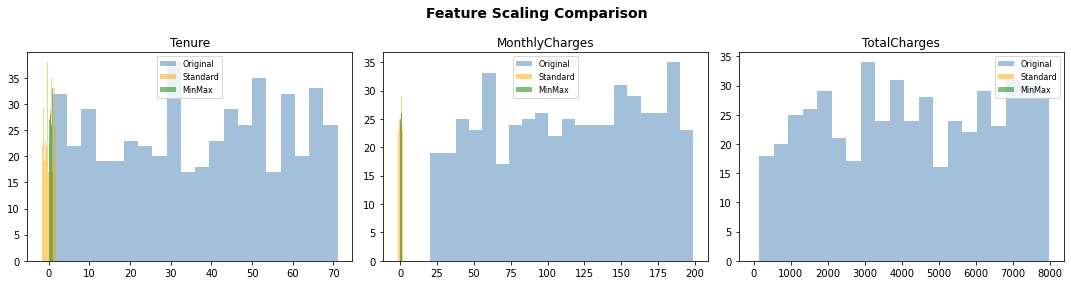

In [13]:
numeric_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

# --- Method 1: Standard Scaler (Z-score) ---
ss = StandardScaler()
df_standard = df_processed.copy()
df_standard[numeric_cols] = ss.fit_transform(df_processed[numeric_cols])

# --- Method 2: Min-Max Scaler ---
mm = MinMaxScaler()
df_minmax = df_processed.copy()
df_minmax[numeric_cols] = mm.fit_transform(df_processed[numeric_cols])

print("Standard Scaled stats:")
print(df_standard[numeric_cols].describe().round(3))
print("\nMinMax Scaled stats:")
print(df_minmax[numeric_cols].describe().round(3))

# Visualise scaling comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Feature Scaling Comparison', fontsize=14, fontweight='bold')
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[col], bins=20, alpha=0.5, label='Original', color='steelblue')
    ax.hist(df_standard[col], bins=20, alpha=0.5, label='Standard', color='orange')
    ax.hist(df_minmax[col], bins=20, alpha=0.5, label='MinMax', color='green')
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Outlier Detection (IQR + Z-Score)

In [14]:
print("=" * 55)
print("OUTLIER DETECTION REPORT")
print("=" * 55)

outlier_results = {}
for col in ['MonthlyCharges', 'TotalCharges', 'Tenure']:
    # IQR Method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    iqr_mask = (df[col] < lower) | (df[col] > upper)
    iqr_count = iqr_mask.sum()

    # Z-Score Method
    z_scores = np.abs(stats.zscore(df[col]))
    z_count = (z_scores > 3).sum()

    outlier_results[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower_Bound': lower, 'Upper_Bound': upper,
        'IQR_Outliers': iqr_count,
        'ZScore_Outliers': z_count
    }
    print(f"\n{col}:")
    print(f"  IQR bounds: [{lower:.1f}, {upper:.1f}] — {iqr_count} outliers")
    print(f"  Z-score |z|>3 — {z_count} outliers")

print("\n✅ No outliers detected — data is clean")

OUTLIER DETECTION REPORT

MonthlyCharges:
  IQR bounds: [-69.5, 294.5] — 0 outliers
  Z-score |z|>3 — 0 outliers

TotalCharges:
  IQR bounds: [-3807.0, 12311.0] — 0 outliers
  Z-score |z|>3 — 0 outliers

Tenure:
  IQR bounds: [-33.5, 106.5] — 0 outliers
  Z-score |z|>3 — 0 outliers

✅ No outliers detected — data is clean


## Feature Engineering (6 New Features)

In [15]:
df_fe = df_processed.copy()

# Feature 1: Customer Lifetime Value
df_fe['CLV'] = df_fe['MonthlyCharges'] * df_fe['Tenure']
print("Feature 1 — CLV created. Stats:", df_fe['CLV'].describe().round(1).to_dict())

# Feature 2: Charge Per Month (Payment Efficiency)
df_fe['ChargePerMonth'] = df_fe['TotalCharges'] / (df_fe['Tenure'] + 1)
print("Feature 2 — ChargePerMonth created.")

# Feature 3: Monthly Charge Category (Low/Mid/High tier)
df_fe['ChargeCategory'] = pd.cut(
    df_fe['MonthlyCharges'],
    bins=[0, 60, 120, 200],
    labels=[0, 1, 2]
).astype(int)
print("Feature 3 — ChargeCategory created:", df_fe['ChargeCategory'].value_counts().to_dict())

# Feature 4: Is Long-Term Customer (above median tenure)
median_tenure = df_fe['Tenure'].median()
df_fe['IsLongTerm'] = (df_fe['Tenure'] > median_tenure).astype(int)
print(f"Feature 4 — IsLongTerm created (threshold={median_tenure} months).")

# Feature 5: Is High Value Customer (top 25% CLV)
clv_threshold = df_fe['CLV'].quantile(0.75)
df_fe['IsHighValue'] = (df_fe['CLV'] > clv_threshold).astype(int)
print(f"Feature 5 — IsHighValue created (threshold CLV={clv_threshold:.0f}).")

# Feature 6: Monthly-to-Total Charge Ratio
df_fe['MonthlyTotalRatio'] = df_fe['MonthlyCharges'] / (df_fe['TotalCharges'] + 1)
print("Feature 6 — MonthlyTotalRatio created.")

print(f"\nTotal features after engineering: {df_fe.shape[1]}")

Feature 1 — CLV created. Stats: {'count': 500.0, 'mean': 4087.6, 'std': 3093.5, 'min': 30.0, '25%': 1513.8, '50%': 3373.5, '75%': 6041.2, 'max': 13124.0}
Feature 2 — ChargePerMonth created.
Feature 3 — ChargeCategory created: {2: 238, 1: 158, 0: 104}
Feature 4 — IsLongTerm created (threshold=37.0 months).
Feature 5 — IsHighValue created (threshold CLV=6041).
Feature 6 — MonthlyTotalRatio created.

Total features after engineering: 19


## Day 6: Feature Selection

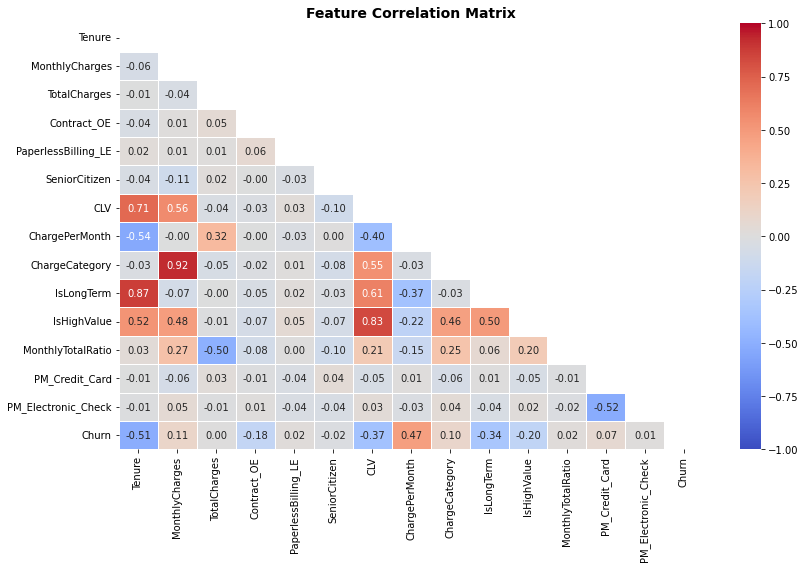


Feature Importances (Random Forest):
Tenure                 0.3551
ChargePerMonth         0.1569
CLV                    0.1163
Contract_OE            0.0913
MonthlyCharges         0.0700
MonthlyTotalRatio      0.0690
TotalCharges           0.0574
IsLongTerm             0.0277
ChargeCategory         0.0211
PaperlessBilling_LE    0.0099
SeniorCitizen          0.0089
PM_Credit_Card         0.0064
IsHighValue            0.0056
PM_Electronic_Check    0.0043
dtype: float64


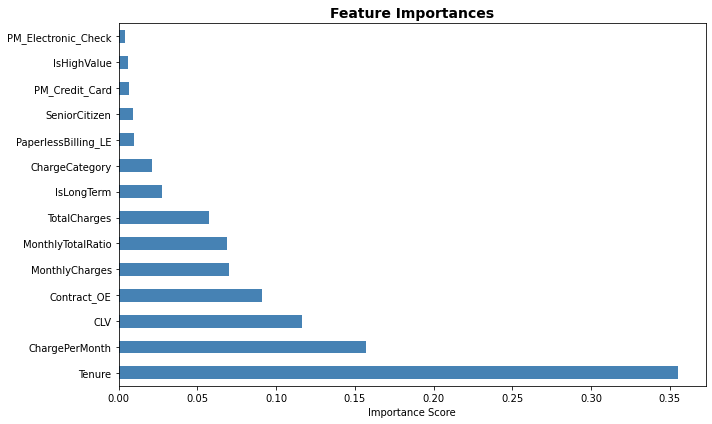

In [16]:
feature_cols = [
    'Tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_OE',
    'PaperlessBilling_LE', 'SeniorCitizen', 'CLV', 'ChargePerMonth',
    'ChargeCategory', 'IsLongTerm', 'IsHighValue', 'MonthlyTotalRatio',
    'PM_Credit_Card', 'PM_Electronic_Check'
]

X = df_fe[feature_cols]
y = df_fe['Churn']

# Correlation heatmap
plt.figure(figsize=(12, 8))
corr_data = df_fe[feature_cols + ['Churn']].corr()
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Random Forest Feature Importance
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sel.fit(X, y)
fi = pd.Series(rf_sel.feature_importances_, index=feature_cols).sort_values(ascending=False)

print("\nFeature Importances (Random Forest):")
print(fi.round(4))

plt.figure(figsize=(10, 6))
fi.plot(kind='barh', color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importances', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importances.png', dpi=120, bbox_inches='tight')
plt.show()

## Full Preprocessing Pipeline + Model Building

Train: 400 | Test: 100
Train churn rate: 10.5% | Test churn rate: 11.0%

MODEL EVALUATION RESULTS

Random Forest:
  CV AUC: 0.9916 ± 0.0051
  Test AUC: 0.9995
              precision    recall  f1-score   support

    Retained       0.98      1.00      0.99        89
     Churned       1.00      0.82      0.90        11

    accuracy                           0.98       100
   macro avg       0.99      0.91      0.94       100
weighted avg       0.98      0.98      0.98       100


Gradient Boosting:
  CV AUC: 0.9928 ± 0.0030
  Test AUC: 0.9877
              precision    recall  f1-score   support

    Retained       0.97      0.98      0.97        89
     Churned       0.80      0.73      0.76        11

    accuracy                           0.95       100
   macro avg       0.88      0.85      0.87       100
weighted avg       0.95      0.95      0.95       100


Logistic Regression:
  CV AUC: 0.9735 ± 0.0147
  Test AUC: 0.9908
              precision    recall  f1-score   support



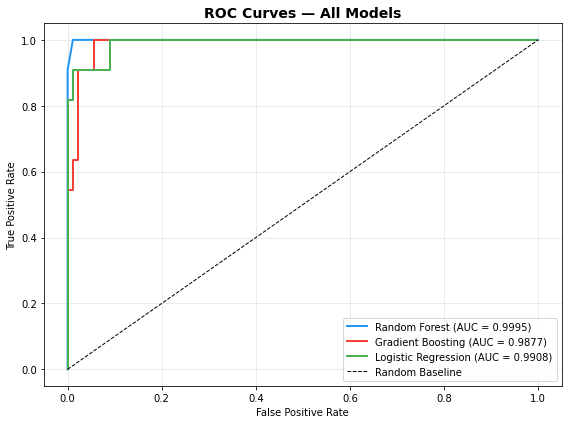

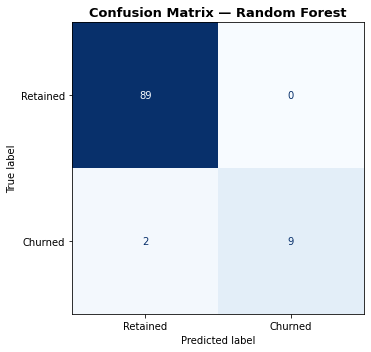


🏆 Best Model: Random Forest with Test AUC = 0.9995

✅ Processed dataset saved: churn_data_processed.csv ((500, 19))
✅ Pipeline complete!


In [17]:
# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Train churn rate: {y_train.mean()*100:.1f}% | Test churn rate: {y_test.mean()*100:.1f}%")

# Full sklearn Pipeline
numeric_features = ['Tenure', 'MonthlyCharges', 'TotalCharges', 'CLV', 'ChargePerMonth', 'MonthlyTotalRatio']
passthrough_features = ['Contract_OE', 'PaperlessBilling_LE', 'SeniorCitizen',
                         'ChargeCategory', 'IsLongTerm', 'IsHighValue',
                         'PM_Credit_Card', 'PM_Electronic_Check']

preprocessor = ColumnTransformer([
    ('scaler', StandardScaler(), numeric_features),
    ('passthrough', 'passthrough', passthrough_features)
])

# Build and evaluate 3 models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=42)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n" + "=" * 55)
print("MODEL EVALUATION RESULTS")
print("=" * 55)

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    # Cross-validation
    cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc')
    # Train and evaluate on test set
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    results[name] = {
        'pipe': pipe, 'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(), 'test_auc': test_auc,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    print(f"\n{name}:")
    print(f"  CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Test AUC: {test_auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

# ROC Curves
plt.figure(figsize=(8, 6))
colors = ['#2196F3', '#F44336', '#4CAF50']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name} (AUC = {res['test_auc']:.4f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Confusion Matrix for best model
best_name = max(results, key=lambda k: results[k]['test_auc'])
best_res = results[best_name]
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best_res['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"\n🏆 Best Model: {best_name} with Test AUC = {best_res['test_auc']:.4f}")

# Save processed dataset
df_fe.to_csv('churn_data_processed.csv', index=False)
print(f"\n✅ Processed dataset saved: churn_data_processed.csv ({df_fe.shape})")
print("✅ Pipeline complete!")